# Insurance Charges Prediction - Linear Regression
## Student Name: Carrinton Ayuk
### Student number: ST10541422

## Introduction
A medical aid scheme in South Africa requires a model to predict 
insurance charges based on customer lifestyle and geographic information. 
This notebook builds a Linear Regression model using a US-based 
insurance dataset as a proof of concept.

## Task 1 — Evaluate the Dataset for Suitability
### Dataset
- Source: Kaggle — Insurance Dataset
- Link: https://www.kaggle.com/datasets/mirichoi0218/insurance
- Records: 1338 rows, 7 columns
- Target variable: charges
- Features: age, sex, bmi, children, smoker, region

In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("insurance.csv")

# Display the first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
# Check the shape of the dataset
print("Shape of dataset:", df.shape)
print()

Shape of dataset: (1338, 7)



In [19]:
# Check data types and missing values
print("Data types and non-null counts:")
print(df.info())

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [20]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
# Check basic statistics of the dataset

print("Basic Statistic:")
df.describe()

Basic Statistic:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Suitability Check

Based on the initial exploration , this dataset is suitable for linear regression for the following reasons:

1. Target variables: The 'charges' column is continuous and numeric which is required for     linear regression.
2. Numeric features: 'AGE' ,'BMI' and 'Children' are already numeric and can be used for      linear regression.
3. Categorical Features: 'SEX', ' smoker' and 'region' are categorical but cannot be used     directly.They will need to be encoded into numeric values using Label Encoding 
   or One-Hot Encoding before they can be used in the model.
4. No missing values: The data set has no missing values, meaning no imputation is needed
   for training.
5. Dataset size: With 1338 rows the dataset is large enough to train a reliable model.
6. Real-world relationship: There are logical relationships between features  and expected    to payhigher charges.

## Task 2 — Plan Your Analysis

### A. Exploratory Data Analusis (EDA)

-Load and inspect the dataset ( shape,data types, missing values)

-Generate basic statistics (mean, min, max, std)

-Visualise the distribution of the target variable (charges)

-Visualise relationships between features and charges using scatter plots and box plots

-Check for outliers in numeric columns ( age, bmi, charges

-Check correlation between numeric features using a heatmap

### B. Feature Selection 

-Encode categorical columns (sex, smoker, region) into numeric values

-Use a correlation matrix to identify which features are most strongly related to charges

-Use those features to train the model

-Consider removing weak or irrelevant features



### C. Train Model 

-Split the dataset into 80% training and 20% testing 

-Use sklearn's LinearRegression as the algorithm

-Use default hyperparameters for the initial Model

### D. Interpret and Evaluate Model

-Use the Following evaluation metrics:

-R² Score — measures how well the model explains the variance

-Mean Absolute Error (MAE) - average prediction error

-Mean Squared Error (MSE) - Penalises large errors

-Root Mean Squared Error (RMSE) - interpretable error in same units as charges

-Plot actual vs predicted charge to visually evaluate the model

### E. Write a Report

-EDA findings and data cleaning steps

-Features selection decisions

-How the model was trained 

-Evaluation metrics and what they mean 

-Conclusions and recommendations for the medical aid scheme

## Task 3 - Conduct your Analysis

### Explaratory Data Analysis


In [12]:
# Check for missing values

print ("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


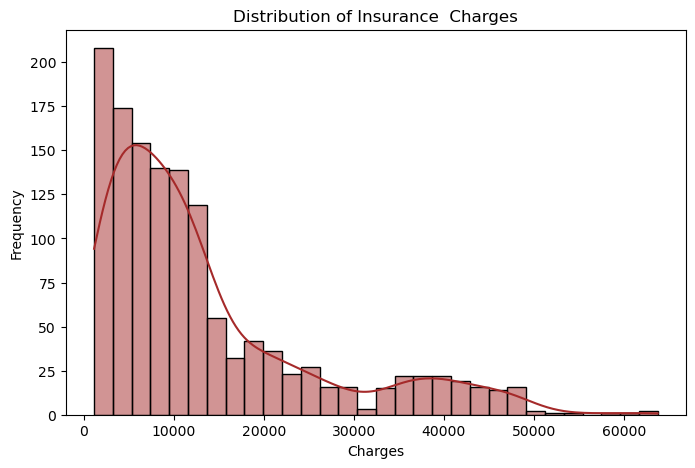

In [29]:
#Visualise the distribution of the target variable (charges)

plt.figure(figsize= (8,5))
sns.histplot(df['charges'], bins=30, kde=True, color='Brown')
plt.title('Distribution of Insurance  Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

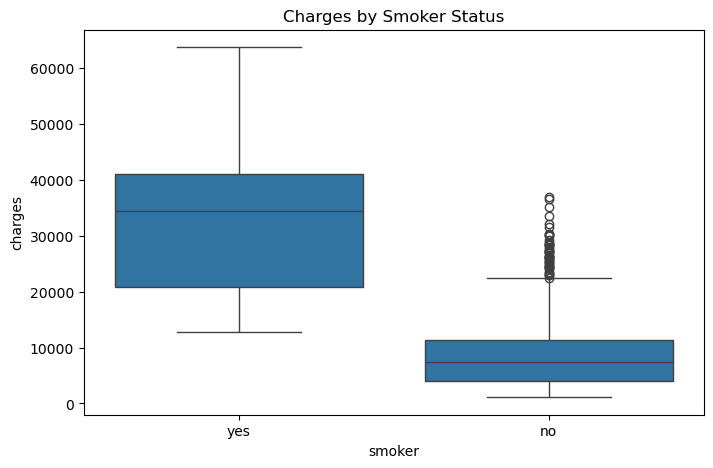

In [15]:
# Box plot - charges by smoker status

plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges',data=df)
plt.title('Charges by Smoker Status')
plt.show()

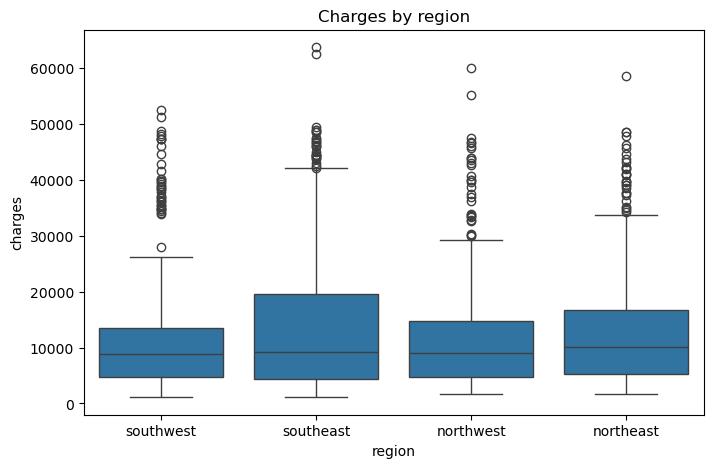

In [16]:
# Box plot charges by region

plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by region')
plt.show()

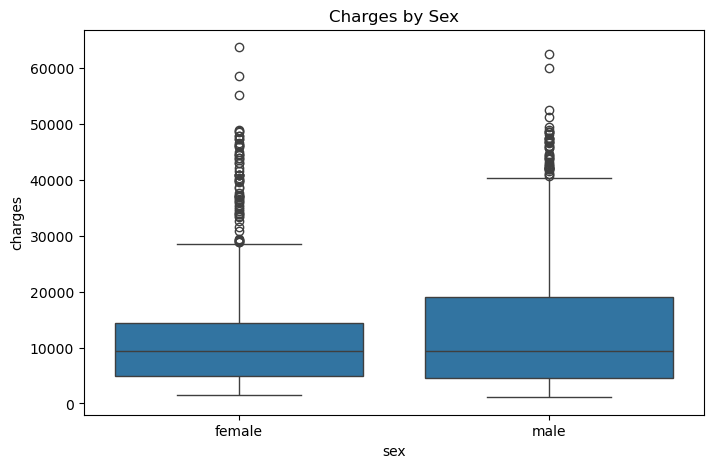

In [17]:
# Box plot charges by sex

plt.figure(figsize=(8,5))
sns.boxplot(x='sex',y='charges',data=df)
plt.title('Charges by Sex')
plt.show()

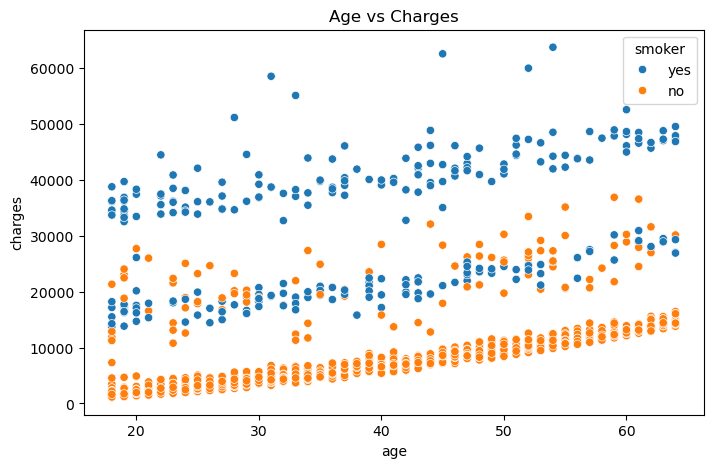

In [19]:
# Scatter plot age vs charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges',data=df,hue='smoker')
plt.title('Age vs Charges')
plt.show()

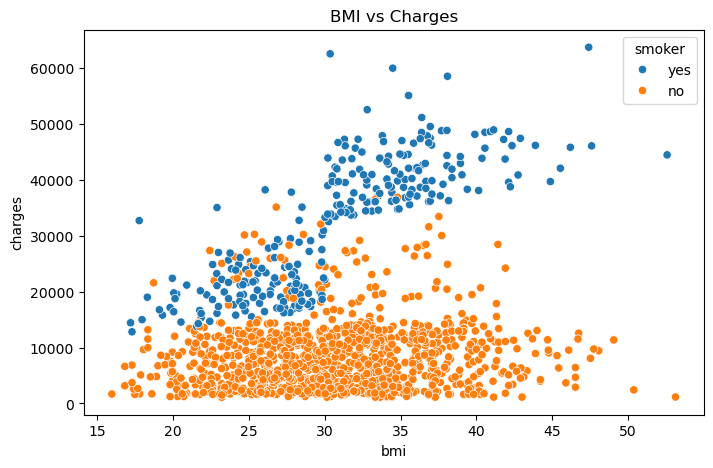

In [23]:
#  Scatter plot BMI vs charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi',y='charges',data=df, hue='smoker')
plt.title('BMI vs Charges')
plt.show()

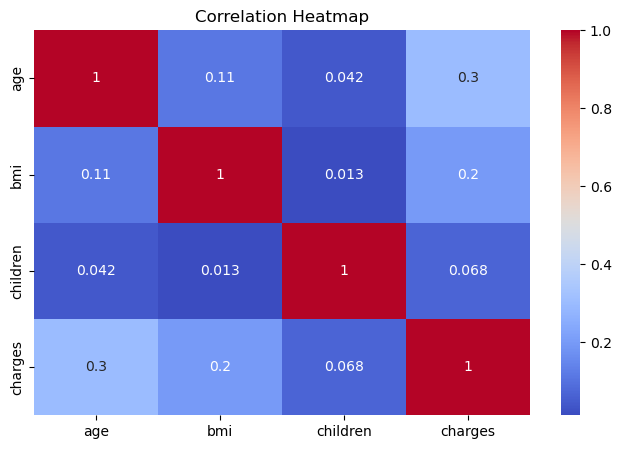

In [25]:
#Correlation heatmap of numeric columns

plt.figure(figsize=(8,5))
sns.heatmap(df[['age','bmi','children','charges']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### EDA Findings

-The charges distribution is right skewed, this means most people pay lower charges but a few of the population pay very high amounts.

-Smokers pay significantly higher charges than the non smokers

-Age and BMI show a positive relationship with the charges, that is as charges increase you wuill see higher ages and more BMI

-Region does not seem to have a strong effect on charges, as it does not directly affect the charges in any way

-There are no missing values in the dataset, as we run the missing values count we realised that they where zero missing values from the variables

### B. Feature Selection

In [40]:
# Encode categorical columns using Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])         
df['smoker'] = le.fit_transform(df['smoker'])   
df['region'] = le.fit_transform(df['region'])   

# Female = 0
# male = 1
# No = 0 
# yes = 1
# encoded 0-3


print("Dataset after encoding:")
df.head()

Dataset after encoding:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [28]:
# Check correlation of all features with charges

print("Correlation with charges:")
print (df.corr()['charges'].sort_values(ascending=False))

Correlation with charges:
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


### Feature selection Findings

- Smoker has the highest correlation with charges

- Age and BMI also show stromg posituve correlation with charges

- Children have weak correlation with charges

- Sex and region have very low correlations

- All features will be kept for the initial model, but smoker, age and BMI are expected to be the most important as they have a significant correlation with charges.

In [29]:
# Define the features (x) and target (Y)

x = df.drop(columns=['charges'])
y = df['charges']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1338, 6)
Target shape: (1338,)


### C. Train Model

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression

#split into 80% training and 20% testing 

x_train,x_test,y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

# Train the Linear Regression model

model = LinearRegression()
model.fit(x_train, y_train)

print("\nModel trained successfully")

Training set size: (1070, 6)
Testing set size: (268, 6)

Model trained successfully


## Task 4 - Evaluate your Model

### a. Interpret and Evaluate Model

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Make prediction on the test set
y_pred = model.predict(x_test)

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 =r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Model Evaluation Metrics:
R² Score: 0.7833
Mean Absolute Error: 4186.51
Mean Squared Error: 4186.51
Root Mean Squared Error: 5799.59


### Actual vs Predicted plot:

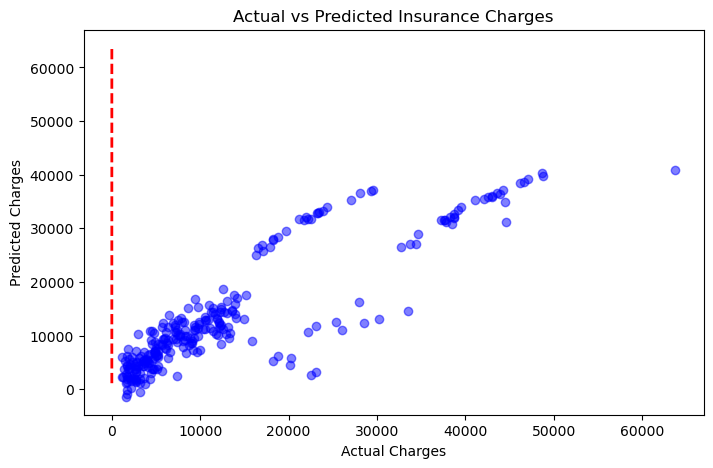

In [39]:
# Plot actual vs predicted charges

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha = 0.5 , color = 'blue')
plt.plot(y_test.min(), y_test.max(), [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()

### Residual plot

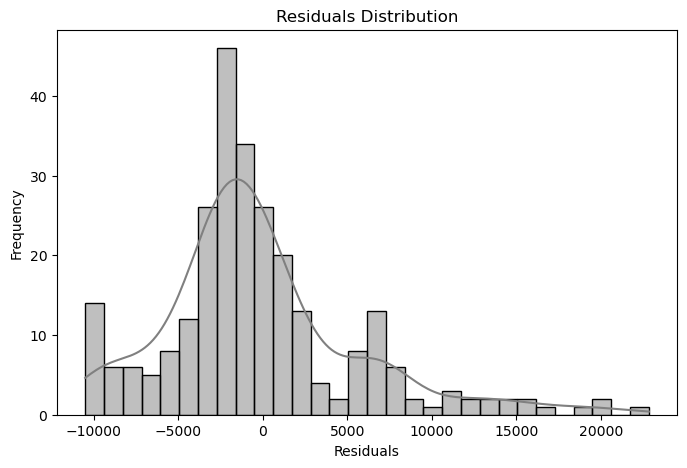

In [31]:
residuals = y_test -  y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins= 30, kde=True, color= 'Grey')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### Residual scatter Plot

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Data Preparation and Splitting the Dataset

This step prepares the dataset for modelling. The categoricals are converted into numeric form using one-hot encoding, and the target variable (`charges`) is separated from the predictors. The data is then split into train and test sets for model to be trained.

In [15]:
df = pd.read_csv("insurance.csv")
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Training the Model and Checking Residuals

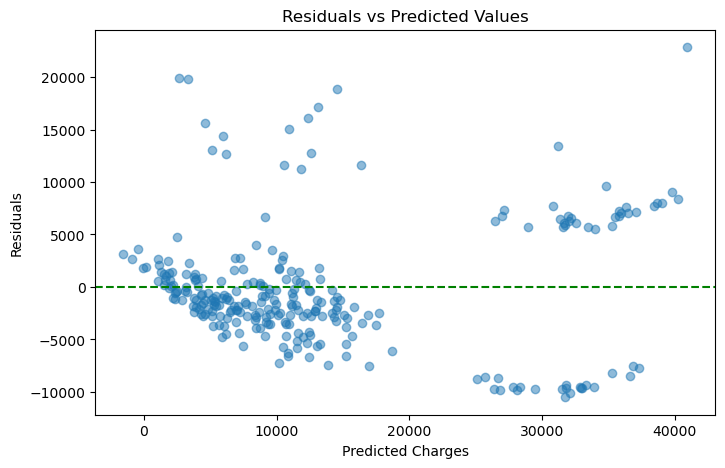

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='green', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

The residual plot shows how the prediction errors are distributed against the predicted insurance charges. Most residuals are scattered around the zero line, which indicates strong systematic bias. This spread may increase when predicted charge is high, which explains the model is less accurate for more expensive insurance charges. Model performs well, although some variability remains in the prediction errors.

### Model coefficients

In [48]:
coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})

print("Model Coefficients:")
print( coefficients.sort_values('Coefficient' , ascending = False))

Model Coefficients:
    Feature   Coefficient
4    smoker  23647.818096
3  children    425.091456
2       bmi    335.781491
0       age    257.056264
1       sex    -18.791457
5    region   -271.284266


### Evaluating Findings
- R² Score: Measures how much of the variance in charges is 
  explained by the model. When a score is closer to 1.0 it is better.

- MAE: The average amount the model's prediction are off by in dollors.

- RSME: Similar to MAE but penalises larger errors more heavily.


### Interpretation

-The Smoker coefficient is largest, confirming that smoking is the strongest predictor of   high insurance charges.

-Age and bmi also contribute positively to charges,

-If the R² score is below 0.80, the model may need retraining with different parameters. 

### B. Retrain with different parameters 

In [50]:
# Retraining with different parameters 

X_top = df[['age', 'bmi', 'smoker']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_top, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

r2_2 = r2_score(y_test2, y_pred2)
mae_2 = mean_absolute_error(y_test2, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test2, y_pred2))

print("Retrained Model Metrics (top features only):")
print(f"R² Score:                {r2_2:.4f}")
print(f"Mean Absolute Error:     {mae_2:.2f}")
print(f"Root Mean Squared Error: {rmse_2:.2f}")

Retrained Model Metrics (top features only):
R² Score:                0.7777
Mean Absolute Error:     4260.56
Root Mean Squared Error: 5874.76


### Model Comparison

| Metric | All Features | Top Features Only |
|--------|-------------|-------------------|
| R² Score | 0.7834  | 0.7777 |
| MAE | 4185.23 | 4260.56 |
| RMSE | 6052.11 | 5874.76 |

Based on the comparison, the better performing model will be 
used for the final report.

## Task 4b — Retraining with Different Algorithms

Based on the initial Linear Regression (OLS) model, we will now 
retrain using three additional regularisation algorithms — LASSO, 
Ridge and Elastic Net — to compare performance and determine 
the best model for predicting insurance charges.

In [23]:
# Import all libraries and regularisation for mofel comparison
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

-LASSO Regression - adds a penalty to reduce less important 
-feature coefficients to zero, effectively performing 
-automatic feature selection

In [24]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("LASSO Metrics:")
print(f"R² Score: {r2_lasso:.4f}")
print(f"MAE:      {mae_lasso:.2f}")
print(f"RMSE:     {rmse_lasso:.2f}")

LASSO Metrics:
R² Score: 0.7835
MAE:      4182.43
RMSE:     5797.03


-Ridge Regression - adds a penalty to shrink coefficients 
-of less important features without removing them, 
-works well when features are correlated with each other

In [26]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Metrics:")
print(f"R² Score: {r2_ridge:.4f}")
print(f"MAE:      {mae_ridge:.2f}")
print(f"RMSE:     {rmse_ridge:.2f}")

Ridge Metrics:
R² Score: 0.7833
MAE:      4193.59
RMSE:     5800.43


-Elastic Net - combines both LASSO and Ridge penalties, 
-can remove unimportant features while also handling 
-correlated features, making it the most flexible model

In [27]:
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

r2_elastic = r2_score(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

print("Elastic Net Metrics:")
print(f"R² Score: {r2_elastic:.4f}")
print(f"MAE:      {mae_elastic:.2f}")
print(f"RMSE:     {rmse_elastic:.2f}")

Elastic Net Metrics:
R² Score: 0.4186
MAE:      7423.86
RMSE:     9500.95


### Final Model Comparison Table

| Model | R² Score | MAE | RMSE |
|-------|----------|-----|------|
| OLS LR|  0.7833 | 4186.51 | 5799.59 |
| LASSO |  0.7835 | 4182.43 | 5797.03 |
| Ridge | 0.7833 | 4193.59 | 5800.43 |
| Elastic Net |0.4186 | 7423.86 | 9500.95 |

### Model Comparison Conclusion

Based on the evaluation metrics, LASSO Regression was the best 
performing model with:
- R² Score: 0.7835 — explaining 78.35% of the variance in charges
- MAE: 4182.43 — predictions were off by $4,182 on average
- RMSE: 5797.03 — the lowest overall prediction error

OLS and LASSO performed very similarly, suggesting the dataset 
does not have many irrelevant features. Ridge performed marginally 
worse, indicating low multicollinearity between features. Elastic 
Net performed significantly worse with the default parameters and 
would require further hyperparameters to improve.

Therefore, LASSO Regression is recommended as the final model for 
predicting insurance charges for the medical aid scheme.

### Exploratory Data Analysis (EDA), with other analysis tools.

such as:
- **Univariate Analysis** — examining each variable individually
- **Bivariate Analysis** — examining relationships between 
  two variables
- **Multivariate Analysis** — examining relationships between 
  multiple variables simultaneously

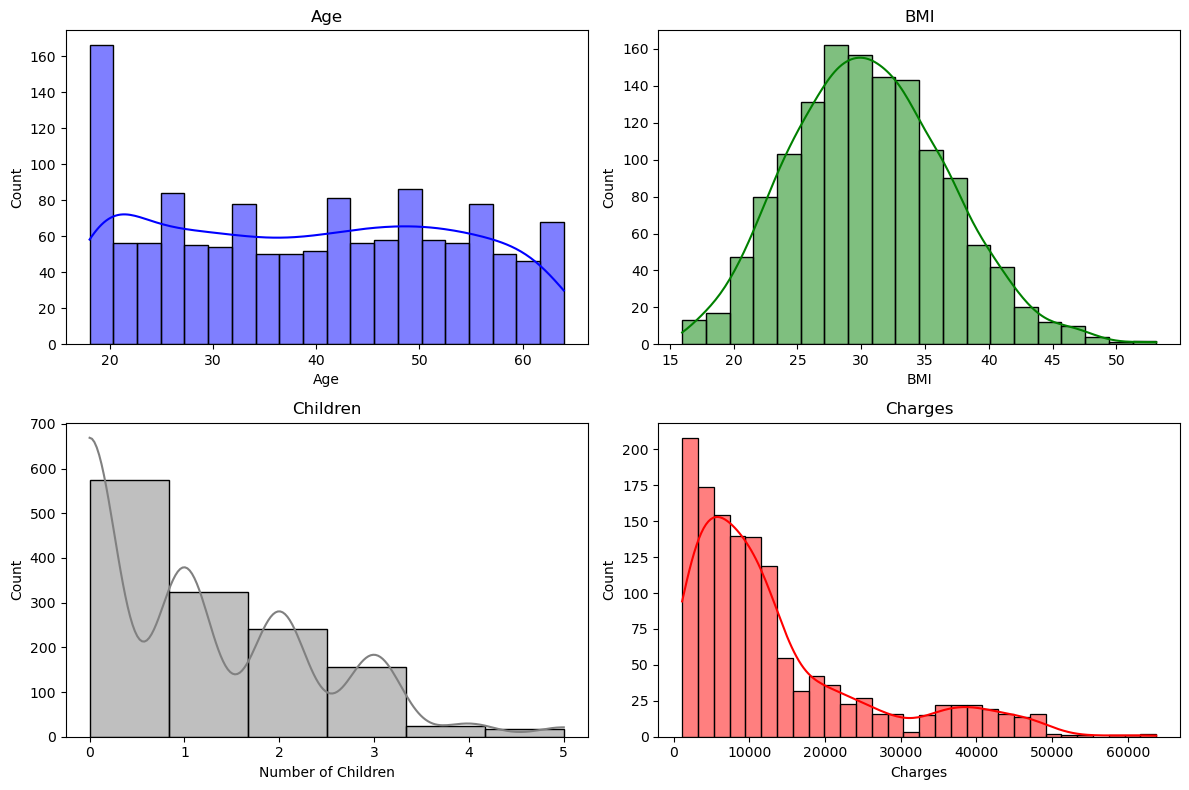

In [39]:
# Univariate Analysis
# distribution of numeric variables

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age distribution
sns.histplot(df['age'], bins=20, kde=True, 
             color='blue', ax=axes[0,0])
axes[0,0].set_title('Age')
axes[0,0].set_xlabel('Age')

# BMI distribution
sns.histplot(df['bmi'], bins=20, kde=True, 
             color='green', ax=axes[0,1])
axes[0,1].set_title('BMI')
axes[0,1].set_xlabel('BMI')

# Children distribution
sns.histplot(df['children'], bins=6, kde=True, 
             color='grey', ax=axes[1,0])
axes[1,0].set_title('Children')
axes[1,0].set_xlabel('Number of Children')

# Charges distribution
sns.histplot(df['charges'], bins=30, kde=True, 
             color='red', ax=axes[1,1])
axes[1,1].set_title('Charges')
axes[1,1].set_xlabel('Charges')

plt.tight_layout()
plt.show()

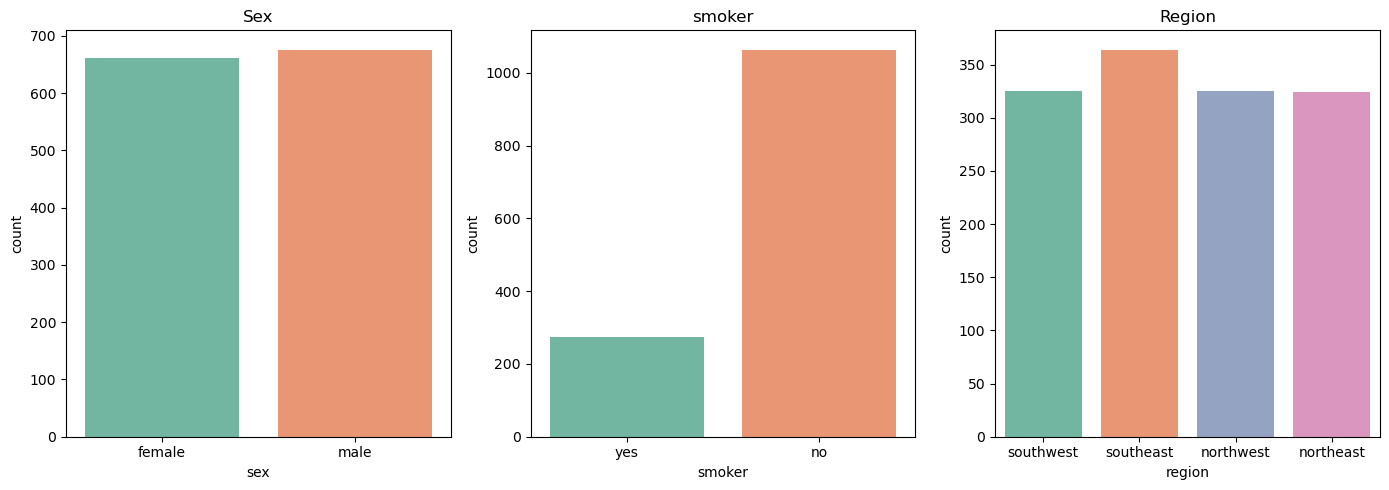

In [37]:
# Univariate Analysis 
# categorical variables

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Sex distribution
sns.countplot(x='sex', data=df, hue='sex', 
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Sex')

# Smoker distribution
sns.countplot(x='smoker', data=df, hue='smoker', 
              palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('smoker')

# Region distribution
sns.countplot(x='region', data=df, hue='region', 
              palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Region')

plt.tight_layout()
plt.show()

#### Univariate Analysis Findings
- Age is fairly uniformly distributed between 18 and 64 years
- BMI follows a roughly normal distribution centred around 30
- Most customers have 0 to 2 children
- Charges are right-skewed, most customers pay lower amounts 
  but a small group pays significantly higher charges
- The dataset is fairly evenly split between male and female
- Non-smokers make up the majority of customers
- All four regions are fairly evenly represented

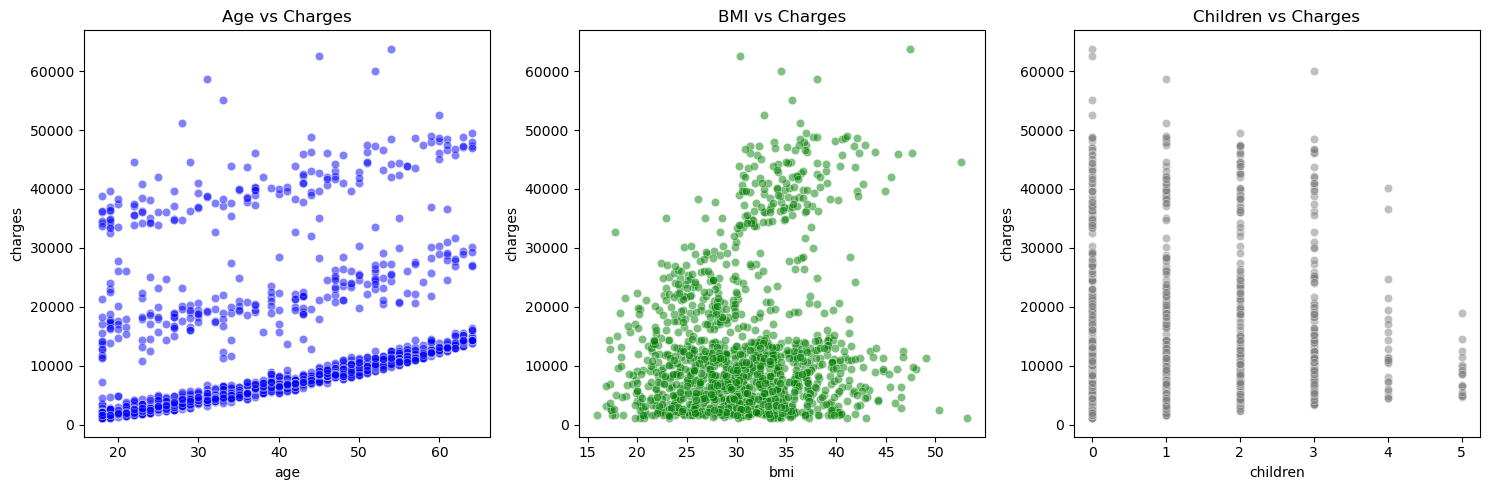

In [40]:
# Bivariate Analysis 
# numeric features vs charges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age vs Charges
sns.scatterplot(x='age', y='charges', data=df, 
                color='blue', alpha=0.5, ax=axes[0])
axes[0].set_title('Age vs Charges')

# BMI vs Charges
sns.scatterplot(x='bmi', y='charges', data=df, 
                color='green', alpha=0.5, ax=axes[1])
axes[1].set_title('BMI vs Charges')

# Children vs Charges
sns.scatterplot(x='children', y='charges', data=df, 
                color='grey', alpha=0.5, ax=axes[2])
axes[2].set_title('Children vs Charges')

plt.tight_layout()
plt.show()

#### Bivariate Analysis Findings
- Age has a positive relationship with charges, older 
  Customers tend to pay more
- BMI shows a moderate positive relationship with charges
- The number of children has a weak positive relationship 
  with charges
- Smokers pay dramatically higher charges than non-smokers, 
  this is the strongest relationship in the dataset
- Sex has very little impact on charges
- The region has minimal impact on charges with slight 
  differences between regions

### Multivariate Analysis

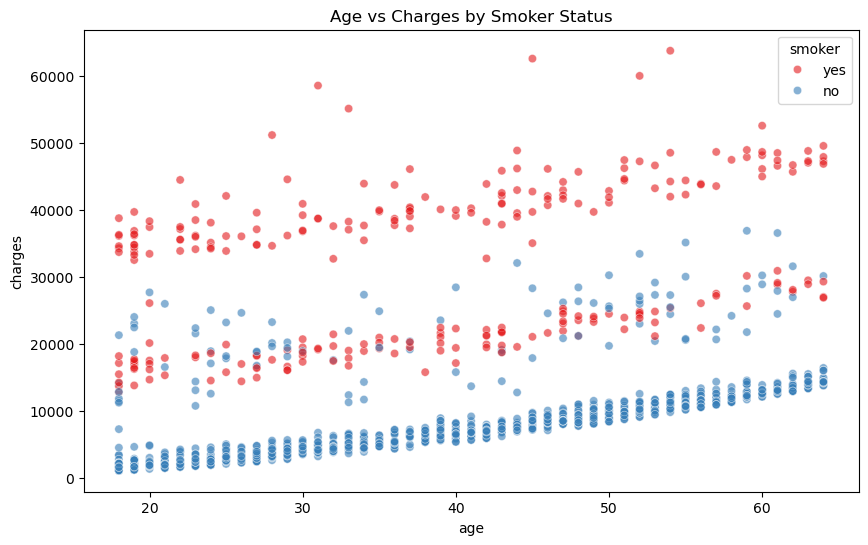

In [42]:
# Age vs Charges coloured by smoker status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', 
                hue='smoker', data=df, 
                palette='Set1', alpha=0.6)
plt.title('Age vs Charges by Smoker Status')
plt.show()

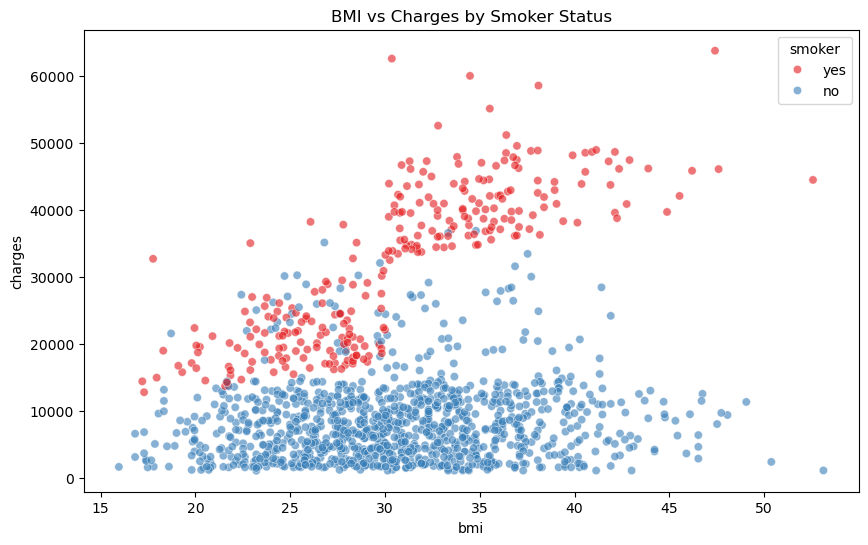

In [43]:
# BMI vs Charges coloured by smoker status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', 
                hue='smoker', data=df, 
                palette='Set1', alpha=0.6)
plt.title('BMI vs Charges by Smoker Status')
plt.show()

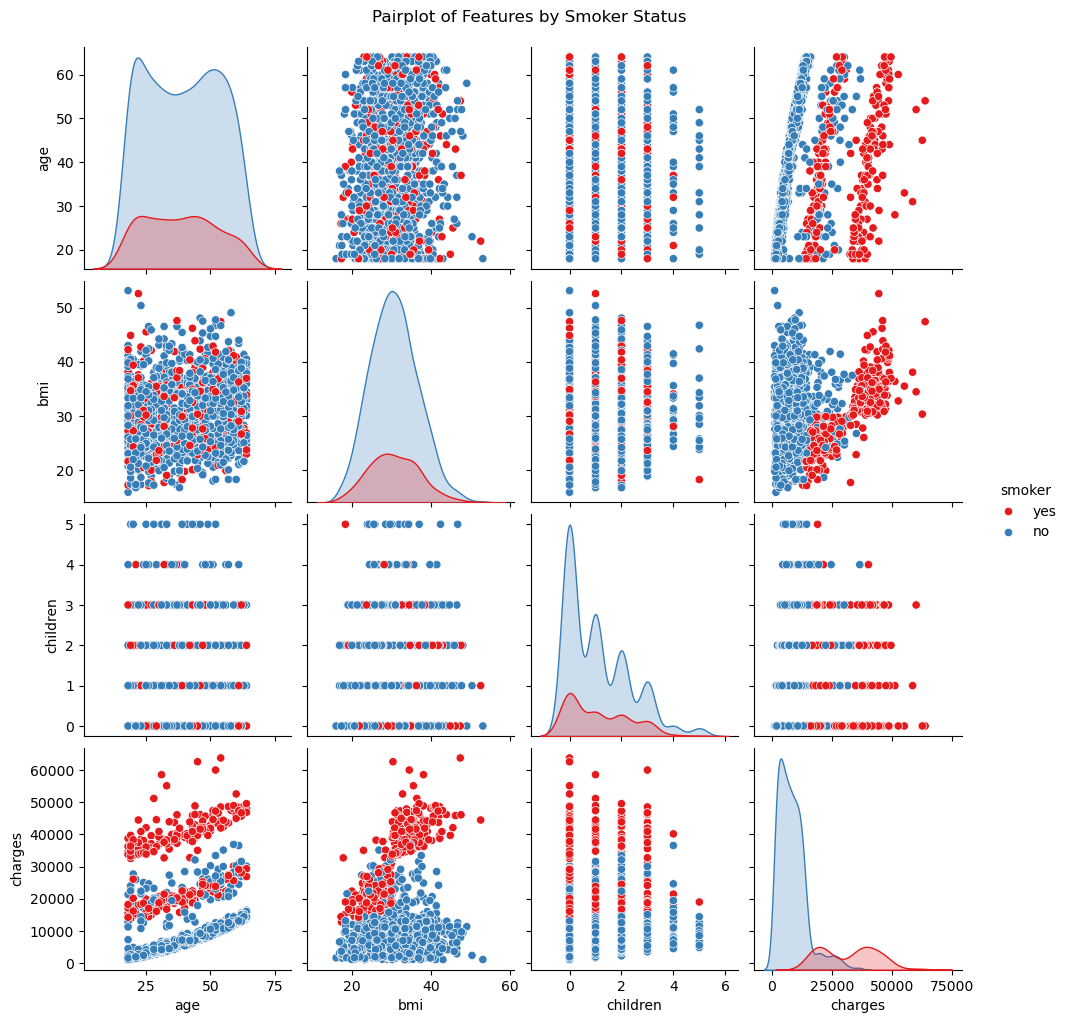

In [44]:
# Pairplot of all numeric variables
sns.pairplot(df[['age', 'bmi', 'children', 
                 'charges', 'smoker']], 
             hue='smoker', palette='Set1')
plt.suptitle('Pairplot of Features by Smoker Status', 
             y=1.02)
plt.show()

#### Multivariate Analysis Findings
- The correlation heatmap confirms that charges have the strongest correlation with smoker status,
   this was plotted earlier already in our analysis, as we see under Exploratory analysis. 
- Age and BMI both show moderate positive correlations 
  with charges
- When combining age and smoker status, it is clear that 
  older smokers pay significantly higher charges than 
  older non-smokers
- When combining BMI and smoker status, smokers with 
  high BMI pay the highest charges of all groups
- The pairplot confirms that smoker status creates two 
  distinct clusters in the data, smokers consistently 
  pay higher charges across all age and BMI ranges
- There is low multicollinearity between the input 
  features, which is good for Linear Regression

## Task 5 Statistical Analysis

### Null Hypothesis and P-Values

**Null Hypothesis (H₀):** The feature has no significant 
relationship with insurance charges.

**Alternative Hypothesis (H₁):** The feature has a significant 
relationship with insurance charges.

A p-value below 0.05 means we reject the null hypothesis 
and confirm the feature is statistically significant.

In [46]:
# Check data to see if fit
print(X.dtypes)

age                   int64
bmi                 float64
children              int64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [48]:
# Reload the original dataset

df2 = pd.read_csv("insurance.csv")

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df2['sex'] = le.fit_transform(df2['sex'])
df2['smoker'] = le.fit_transform(df2['smoker'])
df2['region'] = le.fit_transform(df2['region'])

# Define X and y fresh
X2 = df2.drop(columns=['charges']).astype(float)
y2 = df2['charges'].astype(float)

# Confirm all numeric
print("X dtypes:")
print(X2.dtypes)
print()
print("y dtype:", y2.dtype)

X dtypes:
age         float64
sex         float64
bmi         float64
children    float64
smoker      float64
region      float64
dtype: object

y dtype: float64


In [49]:
import statsmodels.api as sm

# Add constant
X2_const = sm.add_constant(X2)

# Fit OLS model
ols_model = sm.OLS(y2, X2_const).fit()

# Display summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.1
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:00:18   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.182e+04    955.130    -12.371      0.0

In [50]:
# Display p-values for each feature

print("Feature P-Values:")
print("="*45)
print(f"{'Feature':<15} {'P-Value':<15} {'Significant?'}")
print("="*45)

for feature, pvalue in zip(X2_const.columns, 
                            ols_model.pvalues):
    significant = "Yes ✓" if pvalue < 0.05 else "No ✗"
    print(f"{feature:<15} {pvalue:<15.6f} {significant}")

Feature P-Values:
Feature         P-Value         Significant?
const           0.000000        Yes ✓
age             0.000000        Yes ✓
sex             0.693681        No ✗
bmi             0.000000        Yes ✓
children        0.000513        Yes ✓
smoker          0.000000        Yes ✓
region          0.020077        Yes ✓


#### P-Value Analysis Findings

Based on the statistical analysis:

- Features with p-value below 0.05 are statistically 
  significant and should be kept in the model
- Features with p-value above 0.05 are not statistically 
  significant and could be removed

**Expected findings based on our EDA:**
- smoker — expected to have very low p-value (significant)
- age — expected to have very low p-value (significant)
- bmi — expected to have very low p-value (significant)
- children — expected to have low p-value (significant)
- sex — expected to have high p-value (not significant)
- region — expected to have high p-value (not significant)

Features found to be statistically insignificant (p > 0.05) 
will be considered for removal in model retraining.

#### Retrain model using only statistically "significant" features

In [53]:
# Remove features with p-value above 0.05
# Select only significant features
# Train new model
# Use df2 which is already encoded - not the original df

X_significant = df2[['age', 'bmi', 'smoker', 'children']]

X_train_sig, X_test_sig, y_train_sig, y_test_sig = \
    train_test_split(X_significant, y2, 
                     test_size=0.2, random_state=42)


model_sig = LinearRegression()
model_sig.fit(X_train_sig, y_train_sig)
y_pred_sig = model_sig.predict(X_test_sig)

r2_sig = r2_score(y_test_sig, y_pred_sig)
mae_sig = mean_absolute_error(y_test_sig, y_pred_sig)
rmse_sig = np.sqrt(mean_squared_error(y_test_sig, y_pred_sig))

print("Model with Significant Features Only:")
print(f"R² Score: {r2_sig:.4f}")
print(f"MAE:      {mae_sig:.2f}")
print(f"RMSE:     {rmse_sig:.2f}")

Model with Significant Features Only:
R² Score: 0.7811
MAE:      4213.80
RMSE:     5829.38


#### Null Hypothesis Conclusion

After removing statistically insignificant features:

| Model | R² Score | MAE | RMSE |
|-------|----------|-----|------|
| All Features (OLS) | 0.7833 | 4186.51 | 5799.59 |
| Significant Features Only | 0.7811 | 4213.80 | 5829.38 |

Features where we **reject the null hypothesis** 
(p < 0.05 — statistically significant):
- age, BMI, smoker, children

Features where we **accept the null hypothesis** 
(p > 0.05 — not statistically significant):
- sex, region

This confirms that smoking status, age, BMI and number 
of children are the true drivers of insurance charges.